### Lista de Exercícios – Heterocedasticidade, Autocorrelação e Multicolinearidade



**Universidade Federal da Paraíba — Curso de Ciência de Dados para Negócios (CDN)**
**Professor:** Cássio da Nóbrega Besarria
**Aluno(a):** Maria Carolina

In [7]:
!pip install kagglehub pandas

In [28]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub


In [8]:
import kagglehub
import pandas as pd

# Download do dataset
path = kagglehub.dataset_download(
    "mitgandhi10/dataset-for-multiple-linear-regression-2"
)

print("Path:", path)

Path: C:\Users\PC\.cache\kagglehub\datasets\mitgandhi10\dataset-for-multiple-linear-regression-2\versions\1


In [10]:
import os

print(os.listdir(path))

['co2.csv']


In [11]:
import os
import pandas as pd

arquivo_csv = os.path.join(path, "co2.csv")

df = pd.read_csv(arquivo_csv)

print(df.head())

    Make       Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
0  ACURA         ILX       COMPACT             2.0          4          AS5   
1  ACURA         ILX       COMPACT             2.4          4           M6   
2  ACURA  ILX HYBRID       COMPACT             1.5          4          AV7   
3  ACURA     MDX 4WD   SUV - SMALL             3.5          6          AS6   
4  ACURA     RDX AWD   SUV - SMALL             3.5          6          AS6   

  Fuel Type  Fuel Consumption City (L/100 km)  \
0         Z                               9.9   
1         Z                              11.2   
2         Z                               6.0   
3         Z                              12.7   
4         Z                              12.1   

   Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
0                              6.7                               8.5   
1                              7.7                               9.6   
2                   

##### Questão 1: número de obsevações, descrição das variáveis, identificação das variáveis dependentes e das explicativas

In [27]:
print(f"Número de observações: {len(df)}")

Número de observações: 7385


| Variável                           | Tipo     | Descrição                                                                               | Identificação   |
| ---------------------------------- | -------- | --------------------------------------------------------------------------------------- | --------------- |
| `CO2 Emissions(g/km)`              | Numérica | Quantidade de dióxido de carbono emitida pelo veículo, medida em gramas por quilômetro. | **Dependente**  |
| `Engine Size(L)`                   | Numérica | Capacidade do motor do veículo, medida em litros.                                       | **Explicativa** |
| `Cylinders`                        | Numérica | Número de cilindros presentes no motor do veículo.                                      | **Explicativa** |
| `Fuel Consumption City (L/100 km)` | Numérica | Consumo de combustível em ambiente urbano, medido em litros por 100 quilômetros.        | **Explicativa** |
| `Fuel Consumption Hwy (L/100 km)`  | Numérica | Consumo de combustível em rodovias/estradas, medido em litros por 100 quilômetros.      | **Explicativa** |




In [17]:
df = pd.read_csv(arquivo_csv)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [18]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


#### Questão 2: equação estimada, interpretação econômica dos coeficientes e o coeficiente de determinação R2 

In [14]:
import statsmodels.formula.api as smf

modelo = smf.ols(
    'Q("CO2 Emissions(g/km)") ~ Q("Engine Size(L)") + Cylinders + Q("Fuel Consumption City (L/100 km)") + Q("Fuel Consumption Hwy (L/100 km)")',
    data=df
).fit()

print(modelo.summary())

                               OLS Regression Results                               
Dep. Variable:     Q("CO2 Emissions(g/km)")   R-squared:                       0.879
Model:                                  OLS   Adj. R-squared:                  0.879
Method:                       Least Squares   F-statistic:                 1.342e+04
Date:                      dom, 26 jul 2026   Prob (F-statistic):               0.00
Time:                              16:47:24   Log-Likelihood:                -32727.
No. Observations:                      7385   AIC:                         6.546e+04
Df Residuals:                          7380   BIC:                         6.550e+04
Df Model:                                 4                                         
Covariance Type:                  nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

##### Interpretação dos coeficientes
* Intercepto (50,816): representa a emissão média estimada de CO₂ quando todas as variáveis explicativas são iguais a zero. 
* Engine Size(L) (5,526): mantendo as demais variáveis constantes, um aumento de 1 litro no tamanho do motor está associado a um aumento médio de aproximadamente 5,53 g/km nas emissões de CO₂.
* Cylinders (6,534): mantendo as demais variáveis constantes, o acréscimo de um cilindro no motor está associado a um aumento médio de aproximadamente 6,53 g/km nas emissões de CO₂.
* Fuel Consumption City (L/100 km) (7,095): mantendo as demais variáveis constantes, um aumento de 1 L/100 km no consumo urbano está associado a um aumento médio de aproximadamente 7,10 g/km nas emissões de CO₂.
* Fuel Consumption Hwy (L/100 km) (6,252): mantendo as demais variáveis constantes, um aumento de 1 L/100 km no consumo rodoviário está associado a um aumento médio de aproximadamente 6,25 g/km nas emissões de CO₂.
  
##### Qualidade do ajuste
* R² = 0,879: aproximadamente 87,9% da variação das emissões de CO₂ é explicada pelas variáveis explicativas incluídas no modelo.
* R² Ajustado = 0,879: como o R² ajustado é praticamente igual ao R², isso indica que as variáveis incluídas contribuem efetivamente para a explicação da variável dependente, sem evidências de perda de qualidade devido ao excesso de variáveis.


#### Questão 3 : Explique do ponto de vista téorico: a. o que é heterocedasticidade? b. por que ela viola uma hipótese do Modelo Clássico? c. quais são suas consequências para os estimadores de MQO.

* a) O que é heterocedasticidade? R- A heterocedasticidade ocorre quando a variância dos erros (resíduos) não é constante ao longo das observações.
* b) Por que ela viola uma hipótese do Modelo Clássico? Porque o Modelo Clássico de Regressão Linear assume a homocedasticidade, isto é, que todos os erros possuem a mesma variância. Quando a variância dos erros muda entre as observações, essa hipótese é violada.
* c) Quais são suas consequências para os estimadores de MQO? Na presença de heterocedasticidade:
    * Os estimadores de MQO continuam sendo não tendenciosos (não apresentam viés). 
    * Porém, deixam de ser eficientes, ou seja, não possuem mais a menor variância possível.
    * Os erros padrão podem ser estimados incorretamente.
    * Os testes t e F podem produzir conclusões erradas sobre a significância das variáveis.

####  Questão 4 Investigue a existência de heterocedasticidade:  a. realize o teste de Breusch-Pagan ou White; b. apresente as hipóteses do teste; c. interprete os resultados.

In [19]:
# Realize o teste de Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

teste_bp = het_breuschpagan(modelo.resid, modelo.model.exog)

nomes = [
    "LM Statistic",
    "LM-Test p-value",
    "F-Statistic",
    "F-Test p-value"
]

for nome, valor in zip(nomes, teste_bp):
    print(f"{nome}: {valor}")

LM Statistic: 2916.914432385021
LM-Test p-value: 0.0
F-Statistic: 1204.4771852082204
F-Test p-value: 0.0


* b) Hipóteses do teste de Breusch-Pagan
    * H₀ (hipótese nula): os resíduos possuem variância constante (homocedasticidade). 
    * H₁ (hipótese alternativa): os resíduos não possuem variância constante (heterocedasticidade).
* c) Resultados do teste
  * Estatística	Valor 
  * LM Statistic	2916,914
  * p-valor (LM)	0,000
  * F Statistic	1204,477
  * p-valor (F)	0,000
##### Interpretação

* O teste de Breusch-Pagan,  Como os p-valores associados à estatística LM e à estatística F foram inferiores a 0,05, rejeita-se a hipótese nula de homocedasticidade ao nível de significância de 5%. Portanto, conclui-se que há evidências estatísticas de heterocedasticidade nos resíduos do modelo.

* Consequência para o modelo : A presença de heterocedasticidade indica que a variância dos erros não é constante entre as observações. Embora os coeficientes estimados pelo método dos Mínimos Quadrados Ordinários (MQO) continuem não viesados, os erros-padrão podem estar incorretos, tornando os testes t, os testes F e os intervalos de confiança menos confiáveis.

#### Questão 5: Caso exista heterocedasticidade: a. estime erros-padrão robustos; b. compare os resultados com a regressão original; c. explique se houve alteração nas conclusões dos testes t.

In [20]:
modelo_robusto = modelo.get_robustcov_results(cov_type='HC1')

print(modelo_robusto.summary())

                               OLS Regression Results                               
Dep. Variable:     Q("CO2 Emissions(g/km)")   R-squared:                       0.879
Model:                                  OLS   Adj. R-squared:                  0.879
Method:                       Least Squares   F-statistic:                 1.195e+04
Date:                      dom, 26 jul 2026   Prob (F-statistic):               0.00
Time:                              17:09:42   Log-Likelihood:                -32727.
No. Observations:                      7385   AIC:                         6.546e+04
Df Residuals:                          7380   BIC:                         6.550e+04
Df Model:                                 4                                         
Covariance Type:                        HC1                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

* a) Estimação com erros-padrão robustos: Como o teste de Breusch-Pagan indicou a presença de heterocedasticidade (p-valor = 0,000), foram estimados erros-padrão robustos do tipo White (HC1). Essa correção permite obter testes estatísticos mais confiáveis na presença de heterocedasticidade
* b) Comparação com a regressão original : os erros-padrão sofreram alterações, principalmente nas variáveis de consumo de combustível. Como consequência, as estatísticas t diminuíram em magnitude para algumas variáveis.
    Variável              | Coeficiente | Erro-padrão Original | Erro-padrão Robusto |
    | --------------------- | ----------: | -------------------: | ------------------: |
    | Intercepto            |     50,8160 |                1,180 |               1,897 |
    | Engine Size(L)        |      5,5262 |                0,511 |               0,479 |
    | Cylinders             |      6,5339 |                0,356 |               0,371 |
    | Fuel Consumption City |      7,0950 |                0,258 |               0,373 |
    | Fuel Consumption Hwy  |      6,2520 |                0,345 |               0,475 |

* c) Houve alteração nas conclusões dos testes t? Apesar das alterações nos erros-padrão e nas estatísticas t, todos os p-valores permaneceram inferiores a 0,05 (na verdade, próximos de zero). Portanto, todas as variáveis continuaram estatisticamente significativas após a correção robusta.


#### Questão 6: Explique teoricamente o conceito de autocorrelação:a. quando esse problema costuma ocorrer; b. quais hipóteses do MCRL são violadas; c. quais consequências surgem para a inferência estatística.


* a) Quando esse problema costuma ocorrer? Segundo Gujarati, a autocorrelação é encontrada principalmente em dados de séries temporais, pois as observações são ordenadas no tempo e podem apresentar persistência.
* b) Quais hipóteses do MCRL são violadas? A autocorrelação viola a hipótese do Modelo Clássico de Regressão Linear de que os termos de erro são independentes entre si. Logo, a hipótese de ausência de correlação serial entre os erros é violada.

* c) Quais consequências surgem para a inferência estatística? Segundo Gujarati:

       -  Os estimadores de MQO permanecem não viesados, desde que as demais hipóteses sejam satisfeitas. Porém, deixam de ser eficientes (não são mais os melhores estimadores lineares não viesados – BLUE). 
       -  Os erros-padrão estimados tornam-se incorretos.
       -  Os testes t e F podem produzir conclusões enganosas sobre a significância das variáveis.

#### Questão 7: verifique a existência de autocorrelação dos resíduos. : Utilize um procedimento apropriado (Durbin-Watson ou Breusch-Godfrey).Apresente: a. hipóteses do teste; b. estatística obtida; c. conclusão.


In [21]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(modelo.resid)

print("Durbin-Watson:", dw)

Durbin-Watson: 1.7391198232883207


* a) Hipóteses do teste
    - H₀ (hipótese nula): não existe autocorrelação de primeira ordem nos resíduos (ρ=0).
    - H₁ (hipótese alternativa): existe autocorrelação de primeira ordem nos resíduos (ρ=0).
* b) Estatística obtida: O teste apresentou o seguinte resultado= DW=1,7391

     - A estatística de Durbin-Watson varia entre 0 e 4:
        - Valor próximo de 2 → ausência de autocorrelação;
        - Valor inferior a 2 → indício de autocorrelação positiva;
        - Valor superior a 2 → indício de autocorrelação negativa.
* c) Conclusão: O valor obtido para a estatística Durbin-Watson foi de 1,7391. Como esse resultado está relativamente próximo de 2, conclui-se que não há evidências significativas de autocorrelação dos resíduos. Dessa forma, a hipótese nula de ausência de autocorrelação não é rejeitada, indicando que os resíduos podem ser considerados aproximadamente independentes.


#### Questão 8: Construa um gráfico dos resíduos ao longo do tempo (ou na ordem das observações). Discuta se existe algum padrão que sugira autocorrelação.


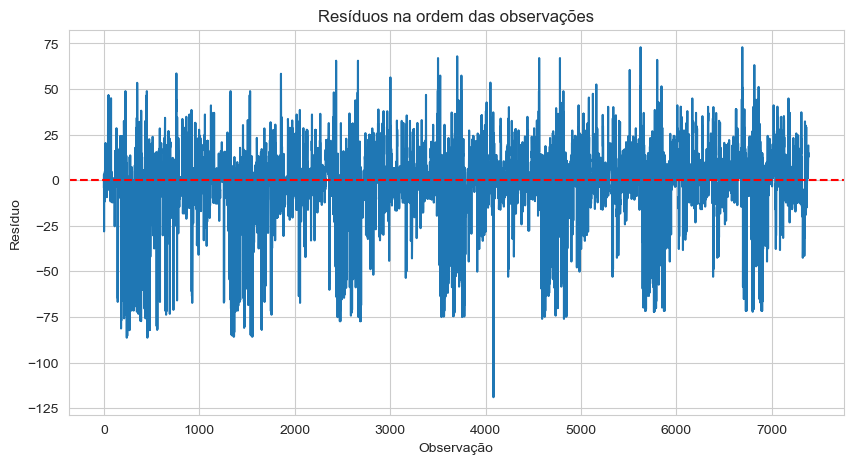

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(modelo.resid)

plt.axhline(y=0, color='red', linestyle='--')

plt.title('Resíduos na ordem das observações')
plt.xlabel('Observação')
plt.ylabel('Resíduo')

plt.show()

* Os resíduos apresentam distribuição aparentemente aleatória em torno da linha zero, sem tendências ou ciclos evidentes. Apesar da presença de alguns valores extremos, não há padrão visual forte que sugira autocorrelação. Essa análise é compatível com o teste de Durbin-Watson (DW = 1,739), que indicou ausência de autocorrelação relevante nos resíduos.

#### Questão 9: Explique o conceito de multicolinearidade e responda: a. diferençaa entre multicolinearidade perfeita e imperfeita; b. efeitos sobre os estimadores; c. por que esse problema dificulta a interpretação econômica.

* a) Diferença entre multicolinearidade perfeita e imperfeita

    - Multicolinearidade perfeita: Ocorre quando existe uma relação linear exata entre as variáveis explicativas. Nesse caso, uma variável pode ser expressa exatamente como combinação linear das demais. Segundo Gujarati, quando a multicolinearidade é perfeita, o modelo não pode ser estimado pelo método dos Mínimos Quadrados Ordinários (MQO), pois a matriz X ′ X torna-se singular.
    - Multicolinearidade imperfeita: Ocorre quando existe uma forte correlação entre as variáveis explicativas, mas não uma relação exata. Essa é a situação mais comum em aplicações empíricas. O modelo pode ser estimado, mas surgem problemas na precisão das estimativas.

* b) Efeitos sobre os estimadores, Segundo Gujarati, na presença de multicolinearidade imperfeita:

    - Os estimadores de MQO continuam sendo não viesados.
    - Os estimadores continuam sendo consistentes.
    - As variâncias e os erros-padrão dos coeficientes aumentam.
    - As estatísticas t tendem a diminuir.
    - Os intervalos de confiança tornam-se mais amplos.
    - Pode ocorrer um alto R2 acompanhado de coeficientes individualmente não significativos.

Portanto, a multicolinearidade não gera viés nos coeficientes, mas reduz a precisão das estimativas.

* c) Por que esse problema dificulta a interpretação econômica?  Segundo Gujarati, quando as variáveis explicativas são altamente correlacionadas, torna-se difícil identificar o efeito isolado de cada uma sobre a variável dependente.


#### Questão 10:  Investigue a existência de multicolinearidade e apresente: a. matriz de correlação; b. Fator de Inflação da Variância (VIF); c. interpretação dos resultados.


                                  Engine Size(L)  Cylinders  \
Engine Size(L)                          1.000000   0.927653   
Cylinders                               0.927653   1.000000   
Fuel Consumption City (L/100 km)        0.831379   0.800702   
Fuel Consumption Hwy (L/100 km)         0.761526   0.715252   

                                  Fuel Consumption City (L/100 km)  \
Engine Size(L)                                            0.831379   
Cylinders                                                 0.800702   
Fuel Consumption City (L/100 km)                          1.000000   
Fuel Consumption Hwy (L/100 km)                           0.948180   

                                  Fuel Consumption Hwy (L/100 km)  
Engine Size(L)                                           0.761526  
Cylinders                                                0.715252  
Fuel Consumption City (L/100 km)                         0.948180  
Fuel Consumption Hwy (L/100 km)                          1.00

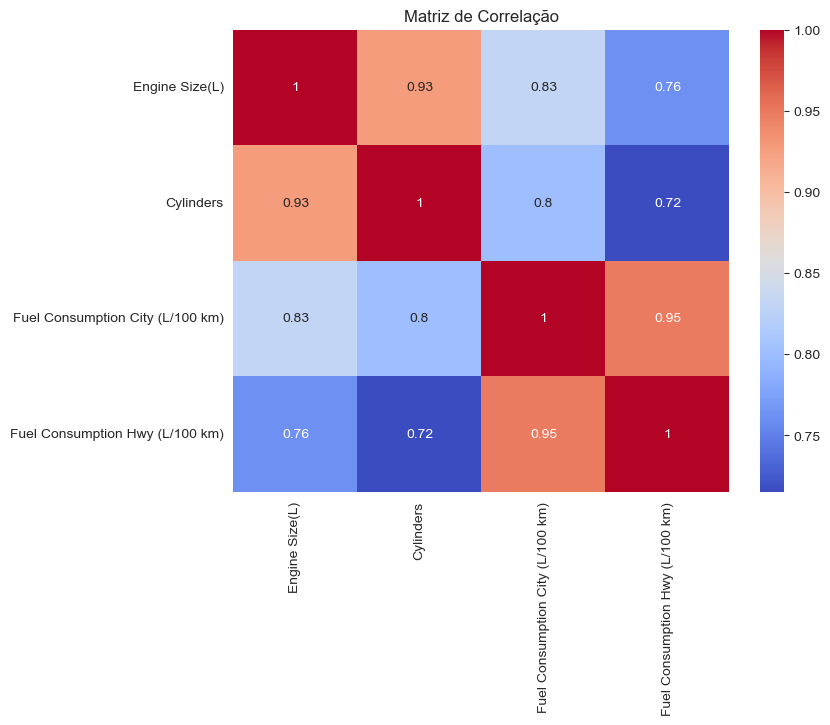

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

X = df[
    [
        "Engine Size(L)",
        "Cylinders",
        "Fuel Consumption City (L/100 km)",
        "Fuel Consumption Hwy (L/100 km)"
    ]
]

corr = X.corr()
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de Correlação")
plt.show()

* A matriz de correlação mostra associações elevadas entre algumas variáveis explicativas. Destacam-se as correlações de 0,928 entre Engine Size(L) e Cylinders, e de 0,948 entre Fuel Consumption City e Fuel Consumption Hwy. Segundo Gujarati, correlações muito altas entre variáveis explicativas podem indicar a presença de multicolinearidade, pois as variáveis passam a fornecer informações semelhantes ao modelo.

In [26]:
#VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = modelo.model.exog

vif = pd.DataFrame()
vif["Variável"] = modelo.model.exog_names
vif["VIF"] = [
    variance_inflation_factor(X_vif, i)
    for i in range(X_vif.shape[1])
]

print(vif)

                                Variável        VIF
0                              Intercept  24.834258
1                    Q("Engine Size(L)")   8.526025
2                              Cylinders   7.571718
3  Q("Fuel Consumption City (L/100 km)")  14.543895
4   Q("Fuel Consumption Hwy (L/100 km)")  10.489871


* c) Interpretação dos resultados

    - O VIF foi utilizado para avaliar a intensidade da multicolinearidade. Segundo Gujarati, valores de VIF superiores a 10 são considerados indicativos de forte multicolinearidade. 
    - Observa-se que as variáveis Fuel Consumption City (VIF = 14,54) e Fuel Consumption Hwy (VIF = 10,49) apresentam valores superiores a 10, indicando forte multicolinearidade. Já as variáveis Engine Size(L) (VIF = 8,53) e Cylinders (VIF = 7,57) apresentam multicolinearidade moderada. 
    - Os resultados da matriz de correlação e do VIF são consistentes entre si, pois as variáveis de consumo de combustível apresentaram tanto correlações elevadas quanto altos valores de VIF.

#### Questão 11: Caso alguma variável apresente elevado VIF, proponha uma estratégia para reduzir a multicolinearidade. Explique as vantagens e desvantagens da solução adotada.

* Para reduzir a multicolinearidade, pode-se retirar a variável Fuel Consumption Hwy (L/100 km) e manter apenas Fuel Consumption City (L/100 km) no modelo.
  * Vantagens: 
    * Redução dos valores de VIF e da multicolinearidade.
    * Diminuição dos erros-padrão dos coeficientes.
    * Maior estabilidade das estimativas.
    * Menor redundância de informações no modelo.
  * Desvantagens:
    * Perda de parte da informação contida na variável removida. 
    * Possível redução do poder explicativo do modelo (R² pode diminuir ligeiramente).
    * O modelo passa a representar apenas um aspecto do consumo de combustível.

#### Questão 12: Considere as seguintes afirmações. Classifique cada uma como verdadeira ou falsa e justifique.



* a) A heterocedasticidade torna os estimadores de MQO viesados. Falso. Segundo Gujarati, a heterocedasticidade não torna os estimadores de MQO viesados nem inconsistentes.
* b) A autocorrelação afeta a eficiência dos estimadores. Verdadeiro. Segundo Gujarati, na presença de autocorrelação os estimadores de MQO permanecem não viesados (sob certas condições), mas deixam de ser eficientes, ou seja, deixam de possuir a menor variância entre os estimadores lineares não viesados (BLUE)
* c) A multicolinearidade aumenta os erros-padrão dos coeficientes. Verdadeiro. Segundo Gujarati, a multicolinearidade não gera viés nos estimadores, mas aumenta suas variâncias e, consequentemente, os erros-padrão dos coeficientes.
* d) Um elevado R² garante ausência de problemas econométricos. Falso. Um elevado R² indica apenas que o modelo explica uma grande parcela da variação da variável dependente. Entretanto, o modelo ainda pode apresentar diversos problemas econométricos, como heterocedasticidade e autocorrelação.

#### Questão 13:Suponha que um pesquisador detectou simultaneamente heterocedasticidade e autocorrelação: Explique: a. quais procedimentos podem ser utilizados para corrigir esses problemas; b. em quais situações o uso de erros-padrão robustos é suficiente; c. quando seria recomend´avel utilizar MQG (GLS ou FGLS).


* a) Quais procedimentos podem ser utilizados para corrigir esses problemas? Quando um modelo apresenta simultaneamente heterocedasticidade e autocorrelação, algumas alternativas são: 
  * Utilizar erros-padrão robustos à heterocedasticidade e autocorrelação, como os erros-padrão de Newey-West. 
  * Aplicar o método dos Mínimos Quadrados Generalizados (MQG ou GLS).
  * Reespecificar o modelo, incluindo variáveis omitidas ou ajustando sua forma funcional
* b) Em quais situações o uso de erros-padrão robustos é suficiente? Segundo Gujarati, os erros-padrão robustos são adequados quando o principal objetivo é realizar inferência estatística confiável, isto é, obter testes t, testes F e intervalos de confiança corretos. 
* C) Quando seria recomendável utilizar MQG (GLS ou FGLS)? O uso de GLS ou FGLS é recomendado quando: 
  * Existe heterocedasticidade e/ou autocorrelação significativa. 
  * Deseja-se obter estimadores mais eficientes.
  * A estrutura da variância dos erros ou da autocorrelação pode ser modelada ou estimada.

#### Questão 14:  Relacione os problemas abaixo com seus respectivos testes de diagnóstico.

| Problema                     | Teste               | Explicação                                                                                          |
| ---------------------------- | ------------------- | --------------------------------------------------------------------------------------------------- |
| **(I) Heterocedasticidade**  | **Breusch-Pagan**   | Verifica se a variância dos resíduos é constante ou não.                                            |
|                              | **White**           | Detecta heterocedasticidade sem assumir uma forma específica para a variância dos erros.            |
| **(II) Autocorrelação**      | **Durbin-Watson**   | Detecta autocorrelação de primeira ordem; valores próximos de 2 indicam ausência de autocorrelação. |
|                              | **Breusch-Godfrey** | Teste mais geral que permite identificar autocorrelação de ordens superiores.                       |
| **(III) Multicolinearidade** | **VIF**             | Mede o grau de correlação entre as variáveis explicativas e identifica multicolinearidade.          |
                         |


#### Questão 15: Parecer Técnico sobre o Modelo de Regressão

Parecer Técnico sobre o Modelo de Regressão

Foi estimado um modelo de regressão linear múltipla para explicar as emissões de dióxido de carbono dos veículos (CO₂ Emissions) a partir das variáveis Engine Size(L), Cylinders, Fuel Consumption City e Fuel Consumption Hwy.

O modelo apresentou bom desempenho, com R² = 0,879 e R² ajustado = 0,879, indicando que aproximadamente 87,9% da variação das emissões de CO₂ é explicada pelas variáveis explicativas incluídas na regressão. Além disso, o teste F apresentou p-valor próximo de zero, indicando significância conjunta do modelo.

Para verificar a presença de heterocedasticidade, foi aplicado o teste de Breusch-Pagan. Os resultados apresentaram p-valor igual a 0,000, levando à rejeição da hipótese nula de homocedasticidade. Portanto, concluiu-se que existe heterocedasticidade nos resíduos do modelo. Para corrigir esse problema, foram estimados erros-padrão robustos (HC1). Após a correção, todas as variáveis permaneceram estatisticamente significativas.

A autocorrelação dos resíduos foi analisada por meio da estatística Durbin-Watson, cujo valor foi de 1,739. Como esse resultado está relativamente próximo de 2, não foram encontradas evidências relevantes de autocorrelação dos resíduos. O gráfico dos resíduos também não apresentou padrões claros que indicassem dependência serial.

A multicolinearidade foi investigada por meio da matriz de correlação e do Fator de Inflação da Variância (VIF). Observou-se elevada correlação entre Fuel Consumption City e Fuel Consumption Hwy (0,948). Os respectivos VIFs foram 14,54 e 10,49, valores superiores ao limite de referência de 10 sugerido por Gujarati. Assim, concluiu-se que existe multicolinearidade relevante entre essas variáveis.

A presença de heterocedasticidade e multicolinearidade possui implicações para a inferência econométrica. A heterocedasticidade torna os erros-padrão incorretos, comprometendo os testes estatísticos, enquanto a multicolinearidade aumenta os erros-padrão dos coeficientes e dificulta a interpretação individual dos efeitos das variáveis explicativas.

Como medida corretiva, recomenda-se a utilização de erros-padrão robustos para lidar com a heterocedasticidade e a possível remoção de uma das variáveis de consumo de combustível para reduzir a multicolinearidade, uma vez que ambas fornecem informações muito semelhantes.

Conclui-se que o modelo apresenta elevada capacidade explicativa e resultados estatisticamente consistentes. Embora tenham sido identificadas heterocedasticidade e multicolinearidade, tais problemas podem ser tratados por meio de técnicas apropriadas, não comprometendo de forma significativa a confiabilidade geral do modelo.